# Avoiding Trajectory Visualization

这个 notebook 只负责可视化 `tools/eval_avoiding_checkpoints.py` 保存出的轨迹数据。

推荐流程：

1. 先用评测脚本生成 JSONL 指标和 `.npz` 轨迹文件。
2. 在这里读取 JSONL，选择一个 `trajectory_path`。
3. 交互式绘制轨迹、查看 mode 分布，并可选保存 PNG。

/home/hulab/projects/world_action_model/d3il_plus/results/cd_npz/seed_0_epoch_eval_best.npz
trajectories: (480, 300, 2)
success_rate: 0.07083333333333333


PosixPath('/home/hulab/projects/world_action_model/d3il_plus/results/avoiding_trajectory_plots/seed_0_epoch_eval_best.png')

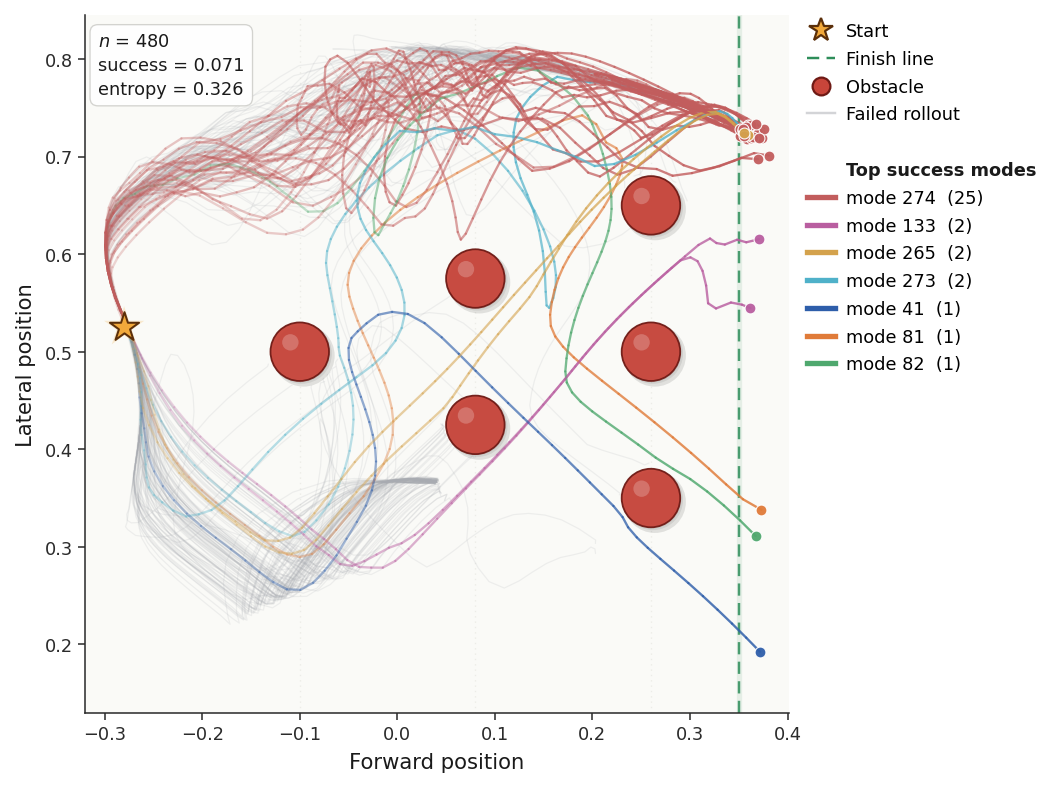

In [ ]:
from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

%matplotlib inline

# ===== 手动配置区 =====
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

RESULT_JSONL = REPO_ROOT / "results" / "avoiding_ddpm_transformer_epoch_curve_best.jsonl"
TRAJECTORY_DIR = REPO_ROOT / "results" / "avoiding_trajectories_npz"

ROW_INDEX = 0
TRAJECTORY_PATH = "/home/hulab/projects/world_action_model/d3il_plus/results/avoiding_trajectories_npz/seed_0_epoch_eval_best.npz"

MAX_TRAJECTORIES = 240
FIGURE_HEIGHT = 5.0
AXIS_PADDING = 0.03
LATERAL_PERCENTILE = 100.0
SAVE_PLOT = True
PLOT_DIR = REPO_ROOT / "results" / "avoiding_trajectory_plots"
PLOT_FILENAME = None
N_LEGEND_MODES = 9           # legend 中显示的 top mode 数
TAPER_TRAJECTORY = True      # 轨迹是否使用渐隐 alpha（comet 风格）

# ===== Nature-style 全局样式 =====
NATURE_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10.5,
    "axes.titleweight": "regular",
    "axes.labelsize": 9.5,
    "axes.linewidth": 0.7,
    "axes.edgecolor": "#2b2b2b",
    "axes.labelcolor": "#1a1a1a",
    "axes.titlepad": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.color": "#2b2b2b",
    "ytick.color": "#2b2b2b",
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.fontsize": 8,
    "legend.frameon": False,
    "savefig.dpi": 400,
    "figure.dpi": 160,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}
mpl.rcParams.update(NATURE_RC)

# 精心调过的定性配色 —— 饱和度受控、相邻区分度高、印刷友好
MODE_PALETTE = [
    "#2E5EAA", "#E07B39", "#4FA86E", "#B95EA0", "#D4A24C",
    "#4FB1C9", "#C25D5D", "#7E6BAC", "#8FA82E", "#A98060",
    "#5894A8", "#D86B7C", "#3B8E8E", "#B97A3D", "#6F8FBF",
    "#9C5D8A", "#508B58", "#C29A4A", "#7B7BCF", "#B05D9C",
]

OBSTACLE_FACE  = "#C8453A"
OBSTACLE_EDGE  = "#6E1A15"
START_FACE     = "#F2A93B"
START_EDGE     = "#5B2F0A"
FINISH_COLOR   = "#2E8E5A"
FAIL_COLOR     = "#A8ABB1"
BG_COLOR       = "#FAFAF7"
GRID_COLOR     = "#ECECE7"
ANNOT_BG       = "#FFFFFF"
ANNOT_EDGE     = "#D0D0CC"


def read_jsonl(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    rows = []
    with path.open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def scalar_value(npz_file, key, default=None):
    if key not in npz_file:
        return default
    value = npz_file[key]
    return value.item() if hasattr(value, "item") else value


def trim_trajectory(trajectory):
    valid = np.abs(trajectory).sum(axis=1) > 0
    if not valid.any():
        return trajectory[:0]
    return trajectory[: np.where(valid)[0][-1] + 1]


def to_plot_xy(points):
    """Rotate display coordinates so task progress goes left to right."""
    points = np.asarray(points)
    return np.column_stack([points[..., 1], points[..., 0]])


def summarize_modes(successes, modes):
    if not successes.any():
        return 0.0, []
    unique_modes, counts = np.unique(modes[successes], return_counts=True)
    mode_probs = counts / counts.sum()
    entropy = float(-(mode_probs * (np.log(mode_probs) / np.log(24))).sum())
    mode_summary = sorted(zip(unique_modes, counts), key=lambda x: x[1], reverse=True)
    return entropy, mode_summary


def sample_trajectory_indices(successes, max_trajectories=240, seed=0):
    total = len(successes)
    if max_trajectories <= 0 or total <= max_trajectories:
        return np.arange(total)
    rng = np.random.default_rng(seed)
    success_idx = np.where(successes)[0]
    failure_idx = np.where(~successes)[0]
    n_success = min(len(success_idx), max_trajectories // 2)
    n_failure = max_trajectories - n_success
    chosen_success = rng.choice(success_idx, size=n_success, replace=False) if n_success else np.array([], dtype=int)
    chosen_failure = rng.choice(failure_idx, size=min(len(failure_idx), n_failure), replace=False) if n_failure else np.array([], dtype=int)
    return np.concatenate([chosen_success, chosen_failure])


def draw_obstacle(ax, cx, cy, radius, zorder=5):
    """带柔和投影 + 高光的障碍物，营造立体感而不喧宾夺主。"""
    # 多层投影，模拟柔和阴影
    for i, (offx, offy, alpha, scale) in enumerate(
        [(0.004, -0.004, 0.10, 1.06),
         (0.002, -0.002, 0.07, 1.03),
         (0.001, -0.001, 0.05, 1.01)]
    ):
        ax.add_patch(Circle(
            (cx + offx, cy + offy), radius * scale,
            facecolor="#000000", edgecolor="none",
            alpha=alpha, zorder=zorder - 1,
        ))
    # 主体
    ax.add_patch(Circle(
        (cx, cy), radius,
        facecolor=OBSTACLE_FACE, edgecolor=OBSTACLE_EDGE,
        lw=0.8, alpha=0.95, zorder=zorder,
    ))
    # 左上高光
    ax.add_patch(Circle(
        (cx - 0.32 * radius, cy + 0.32 * radius), 0.28 * radius,
        facecolor="#FFFFFF", edgecolor="none",
        alpha=0.22, zorder=zorder + 1,
    ))


def add_tapered_line(ax, points, color, lw=1.0, alpha_start=0.18, alpha_end=0.92, zorder=3):
    """轨迹做渐隐 alpha，起点淡、终点亮，视觉上有方向感。"""
    if len(points) < 2:
        return
    segments = np.stack([points[:-1], points[1:]], axis=1)
    alphas = np.linspace(alpha_start, alpha_end, len(segments))
    colors = np.array([to_rgba(color, a) for a in alphas])
    lc = LineCollection(segments, colors=colors, linewidths=lw,
                        capstyle="round", joinstyle="round", zorder=zorder)
    lc.set_clip_on(False)
    ax.add_collection(lc)


def plot_avoiding_trajectories(
    trajectories,
    successes,
    modes,
    seed=None,
    epoch=None,
    max_trajectories=240,
    figure_height=5.0,
    axis_padding=0.03,
    lateral_percentile=99.0,
):
    draw_indices = sample_trajectory_indices(successes, max_trajectories=max_trajectories)

    OBSTACLE_RADIUS = 0.03
    obstacle_specs = [
        (0.5, -0.1, OBSTACLE_RADIUS),
        (0.425, 0.08, OBSTACLE_RADIUS),
        (0.575, 0.08, OBSTACLE_RADIUS),
        (0.35, 0.26, OBSTACLE_RADIUS),
        (0.5, 0.26, OBSTACLE_RADIUS),
        (0.65, 0.26, OBSTACLE_RADIUS),
    ]
    level_y_values = [-0.1, 0.08, 0.26]
    finish_y = -0.1 + 2.5 * 0.18
    start_point = (0.525, -0.28)

    plot_trajectories, lateral_values, forward_values = [], [], []
    for trajectory in trajectories:
        trimmed = trim_trajectory(trajectory)
        pts = to_plot_xy(trimmed[:, :2]) if len(trimmed) else trimmed[:, :2]
        plot_trajectories.append(pts)
        if len(trimmed):
            lateral_values.append(trimmed[:, 0])
            forward_values.append(trimmed[:, 1])

    forward_values = np.concatenate(forward_values) if forward_values else np.array([-0.28, finish_y])
    lateral_values = np.concatenate(lateral_values) if lateral_values else np.array([0.2, 0.6])

    forward_min = float(min(forward_values.min(), -0.28, finish_y))
    forward_max = float(max(forward_values.max(), finish_y, -0.28))
    obstacle_lateral = [x for x, _, _ in obstacle_specs]
    obstacle_radius  = [r for _, _, r in obstacle_specs]
    must_lo = min([start_point[0], 0.15] + [x - r for x, r in zip(obstacle_lateral, obstacle_radius)])
    must_hi = max([start_point[0], 0.65] + [x + r for x, r in zip(obstacle_lateral, obstacle_radius)])
    lateral_lo = float(min(np.percentile(lateral_values, 100 - lateral_percentile), must_lo))
    lateral_hi = float(max(np.percentile(lateral_values, lateral_percentile), must_hi))

    forward_span = max(forward_max - forward_min, 1e-6)
    lateral_span = max(lateral_hi - lateral_lo, 1e-6)
    pad_f = axis_padding * forward_span
    pad_l = axis_padding * lateral_span
    xy_min = np.array([forward_min - pad_f, lateral_lo - pad_l])
    xy_max = np.array([forward_max + pad_f, lateral_hi + pad_l])
    forward_span = xy_max[0] - xy_min[0]
    lateral_span = xy_max[1] - xy_min[1]
    fig_width = figure_height * forward_span / lateral_span + 1.2  # 给 legend 留白

    fig, ax = plt.subplots(figsize=(fig_width, figure_height), dpi=160)
    fig.patch.set_facecolor("white")
    ax.set_facecolor(BG_COLOR)

    # 极淡的水平参考线（关卡）
    for level_y in level_y_values:
        ax.axvline(level_y, color=GRID_COLOR, lw=0.6, ls=(0, (1, 3)), alpha=1.0, zorder=1)

    # finish line：双线，主线 + 极淡光晕
    ax.axvline(finish_y, color=FINISH_COLOR, lw=2.4, alpha=0.10, zorder=1.5)
    ax.axvline(finish_y, color=FINISH_COLOR, lw=1.1, ls=(0, (5, 3)), alpha=0.85, zorder=2)

    # 障碍物（带阴影 + 高光）
    for x, y, radius in obstacle_specs:
        plot_x, plot_y = to_plot_xy([[x, y]])[0]
        draw_obstacle(ax, plot_x, plot_y, radius, zorder=5)

    # mode → color
    successful_modes = sorted(set(modes[successes]))
    mode_to_color = {m: MODE_PALETTE[i % len(MODE_PALETTE)] for i, m in enumerate(successful_modes)}

    # 失败轨迹（先画，作为背景）
    for idx in draw_indices:
        if successes[idx]:
            continue
        traj = plot_trajectories[idx]
        if len(traj) < 2:
            continue
        line, = ax.plot(traj[:, 0], traj[:, 1], color=FAIL_COLOR,
                        lw=0.55, alpha=0.16, zorder=2, solid_capstyle="round")
        line.set_clip_on(False)

    # 成功轨迹（前景，渐隐 alpha）
    for idx in draw_indices:
        if not successes[idx]:
            continue
        traj = plot_trajectories[idx]
        if len(traj) < 2:
            continue
        color = mode_to_color.get(modes[idx], MODE_PALETTE[0])
        if TAPER_TRAJECTORY:
            add_tapered_line(ax, traj, color, lw=1.05,
                             alpha_start=0.18, alpha_end=0.85, zorder=3)
        else:
            line, = ax.plot(traj[:, 0], traj[:, 1], color=color,
                            lw=1.0, alpha=0.7, zorder=3)
            line.set_clip_on(False)
        # 终点小圆点 + 浅色光晕
        ax.scatter(traj[-1, 0], traj[-1, 1], s=24,
                   facecolor=color, edgecolor="white", lw=0.5,
                   alpha=0.95, zorder=4, clip_on=False)

    # 起点：双层星标（光晕 + 主体）
    sx, sy = to_plot_xy([list(start_point)])[0]
    ax.scatter([sx], [sy], marker="*", s=360, color=START_FACE,
               edgecolor="none", alpha=0.22, zorder=6)
    ax.scatter([sx], [sy], marker="*", s=190, color=START_FACE,
               edgecolor=START_EDGE, lw=0.9, zorder=7)

    # 标题：极简，metric 移到注释框
    seed_label = seed if seed is not None and seed != "unknown" else "—"
    epoch_label = epoch if epoch is not None and epoch != "unknown" else "—"
    # ax.set_title(f"Avoiding rollouts  ·  seed {seed_label}  ·  epoch {epoch_label}",
    #              loc="left", color="#1a1a1a")

    # 坐标轴
    ax.set_xlabel("Forward position")
    ax.set_ylabel("Lateral position")
    ax.set_xlim(xy_min[0], xy_max[0])
    ax.set_ylim(xy_min[1], xy_max[1])
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis="both", which="major", pad=2.5)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#2b2b2b")
        ax.spines[spine].set_linewidth(0.7)
    ax.grid(False)

    # Stats 注释框（右下）
    success_rate = float(successes.mean()) if len(successes) else 0.0
    entropy, mode_summary = summarize_modes(successes, modes)
    stats_text = (f"$n$ = {len(successes)}\n"
                  f"success = {success_rate:.3f}\n"
                  f"entropy = {entropy:.3f}")
    ax.text(
    0.018, 0.975, stats_text, transform=ax.transAxes,
    fontsize=8, ha="left", va="top", color="#1a1a1a",
    linespacing=1.4,
    bbox=dict(boxstyle="round,pad=0.45", facecolor=ANNOT_BG,
              edgecolor=ANNOT_EDGE, lw=0.6, alpha=0.92),
)

    # Legend：结构元素 + 高频 mode
    legend_items = [
        Line2D([0], [0], marker="*", color="w",
               markerfacecolor=START_FACE, markeredgecolor=START_EDGE,
               markersize=11, label="Start"),
        Line2D([0], [0], color=FINISH_COLOR, lw=1.1, ls=(0, (5, 3)), label="Finish line"),
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=OBSTACLE_FACE, markeredgecolor=OBSTACLE_EDGE,
               markersize=8, label="Obstacle"),
        Line2D([0], [0], color=FAIL_COLOR, lw=1.1, alpha=0.5, label="Failed rollout"),
    ]
    # 分隔
    legend_items.append(Line2D([0], [0], color="none", label=" "))
    legend_items.append(Line2D([0], [0], color="none", label="Top success modes"))
    for mode, count in mode_summary[:N_LEGEND_MODES]:
        legend_items.append(
            Line2D([0], [0], color=mode_to_color.get(mode, MODE_PALETTE[0]),
                   lw=2.4, label=f"mode {mode}  ({count})")
        )

    leg = ax.legend(
        handles=legend_items, loc="upper left", bbox_to_anchor=(1.015, 1.0),
        borderaxespad=0.0, handlelength=1.6, handletextpad=0.6,
        labelspacing=0.55, fontsize=8,
    )
    for text in leg.get_texts():
        if text.get_text() == "Top success modes":
            text.set_fontweight("bold")
            text.set_color("#1a1a1a")

    fig.tight_layout()
    return fig, ax


# ===== 主流程 =====
results = read_jsonl(RESULT_JSONL)
if results.empty:
    npz_paths = sorted(TRAJECTORY_DIR.glob("*.npz"))
    results = pd.DataFrame({"trajectory_path": [str(p) for p in npz_paths]})

if TRAJECTORY_PATH is not None:
    trajectory_path = Path(TRAJECTORY_PATH)
elif results.empty:
    raise FileNotFoundError("没有找到 JSONL 结果或 NPZ 轨迹文件。")
else:
    trajectory_path = Path(results.loc[ROW_INDEX, "trajectory_path"])

trajectory_data = np.load(trajectory_path, allow_pickle=True)
trajectories  = trajectory_data["trajectories"]
successes     = trajectory_data["successes"].astype(bool)
mode_encoding = trajectory_data["mode_encoding"]
modes = (trajectory_data["mode_ids"] if "mode_ids" in trajectory_data
         else mode_encoding.astype(np.int64).dot(1 << np.arange(mode_encoding.shape[-1])))
checkpoint  = str(scalar_value(trajectory_data, "checkpoint", ""))
seed        = int(scalar_value(trajectory_data, "seed", -1))
epoch       = int(scalar_value(trajectory_data, "epoch", -1))
epoch_label = scalar_value(trajectory_data, "epoch_label", epoch if epoch >= 0 else "unknown")

print(trajectory_path)
print("trajectories:", trajectories.shape)
print("success_rate:", float(successes.mean()) if len(successes) else 0.0)

fig, ax = plot_avoiding_trajectories(
    trajectories, successes, modes,
    seed=seed if seed >= 0 else "unknown",
    epoch=epoch_label,
    max_trajectories=MAX_TRAJECTORIES,
    figure_height=FIGURE_HEIGHT,
    axis_padding=AXIS_PADDING,
    lateral_percentile=LATERAL_PERCENTILE,
)

plot_path = None
if SAVE_PLOT:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    plot_filename = PLOT_FILENAME or f"{trajectory_path.stem}.png"
    plot_path = PLOT_DIR / plot_filename
    fig.savefig(plot_path, bbox_inches="tight", facecolor="white")
    # 同时存一份矢量图，期刊投稿用
    fig.savefig(plot_path.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")

plot_path